# Predictive Maintenance — Downtime Prediction

This notebook demonstrates an end-to-end ML workflow using a synthetic dataset to predict machine downtime. It is organized for clarity and reproducibility.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import joblib

print('Libraries imported')

Libraries imported


In [12]:
# Load dataset from the project folder
df = pd.read_csv('synthetic_downtime_data.csv')
df.head()

,Temperature,Vibration,Load,Runtime_Hours,Error_Count,Maintenance_Overdue,Downtime
0,74.967142,3.486939,82.295862,592.904524,1,1,0
1,68.617357,6.101434,78.538915,821.415576,1,1,0
2,76.476885,7.546587,67.804836,1221.560391,2,1,1
3,85.230299,6.238958,99.325762,609.320918,3,1,1
4,67.658466,3.176756,80.288741,1285.882925,3,0,0


In [13]:
# Basic info and statistics
print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())

Shape: (250, 7)

Missing values:
 Temperature            0
Vibration              0
Load                   0
Runtime_Hours          0
Error_Count            0
Maintenance_Overdue    0
Downtime               0
dtype: int64


In [14]:
# Statistical summary
print('\nDescribe:')
print(df.describe())


Describe:
       Temperature   Vibration        Load  Runtime_Hours  Error_Count  \
count   250.000000  250.000000  250.000000     250.000000   250.000000   
mean     69.975771    5.019319   74.105363    1087.607086     1.976000   
std       9.660537    1.197688   14.401004     556.815931     1.382414   
min      43.802549    1.110479   50.231601     120.892074     0.000000   
25%      63.207510    4.153180   60.646112     593.061440     1.000000   
50%      70.592195    4.998363   73.117140    1129.358404     2.000000   
75%      75.828654    5.814659   86.752502    1590.844270     3.000000   
max     108.527315    8.694657   99.843713    1996.074810     6.000000   

       Maintenance_Overdue   Downtime  
count           250.000000  250.00000  
mean              0.548000    0.21600  
std               0.498689    0.41234  
min               0.000000    0.00000  
25%               0.000000    0.00000  
50%               1.000000    0.00000  
75%               1.000000    0.00000  
ma

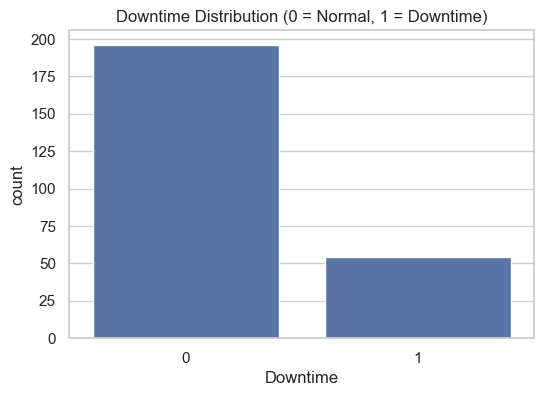

In [15]:
# Distribution of target
plt.figure(figsize=(6,4))
sns.countplot(x='Downtime', data=df)
plt.title('Downtime Distribution (0 = Normal, 1 = Downtime)')
plt.show()

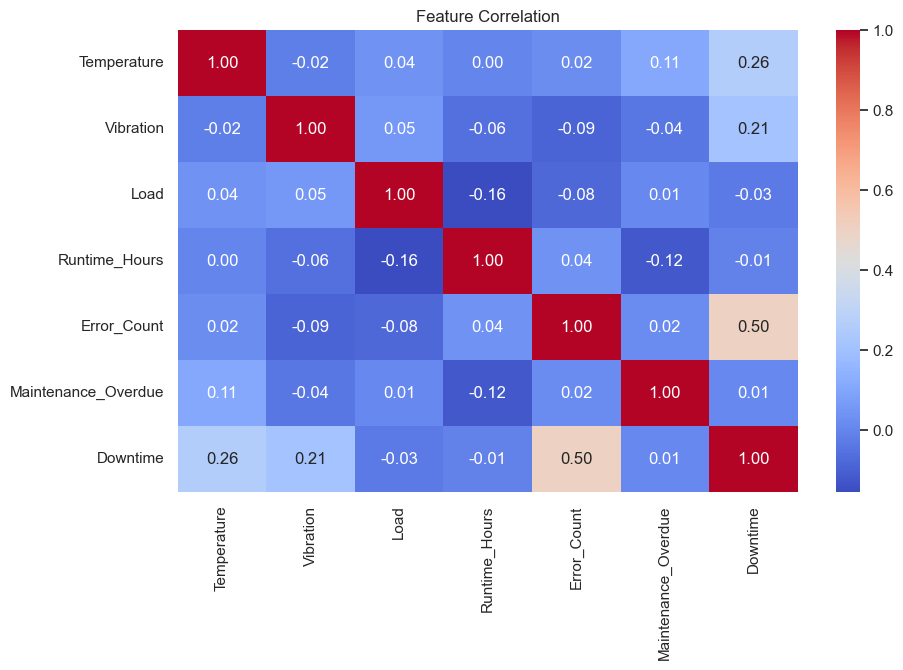

In [16]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [18]:
# Feature engineering: add a couple interaction features that might be useful
df['Temp_x_Vib'] = df['Temperature'] * df['Vibration']
# Show new features
df.head()

,Temperature,Vibration,Load,Runtime_Hours,Error_Count,Maintenance_Overdue,Downtime,Temp_x_Vib
0,74.967142,3.486939,82.295862,592.904524,1,1,0,261.405869
1,68.617357,6.101434,78.538915,821.415576,1,1,0,418.664298
2,76.476885,7.546587,67.804836,1221.560391,2,1,1,577.139502
3,85.230299,6.238958,99.325762,609.320918,3,1,1,531.748280
4,67.658466,3.176756,80.288741,1285.882925,3,0,0,214.934441


In [19]:
# Prepare X, y
X = df.drop(['Downtime'], axis=1)
y = df['Downtime']

In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (187, 7) Test shape: (63, 7)


In [21]:
# Handle imbalance with SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print('After SMOTE - Train shape:', X_train_res.shape)

After SMOTE - Train shape: (294, 7)


In [22]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Save scaler for later
joblib.dump(scaler, 'scaler.save')
print('Scaler saved as scaler.save')

Scaler saved as scaler.save


In [24]:
# Train a baseline Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=10, random_state=42)
rf.fit(X_train_scaled, y_train_res)

RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=200,
                       random_state=42)

In [25]:
# Predict and evaluate
y_pred = rf.predict(X_test_scaled)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.9365079365079365

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        49
           1       0.78      1.00      0.88        14

    accuracy                           0.94        63
   macro avg       0.89      0.96      0.92        63
weighted avg       0.95      0.94      0.94        63



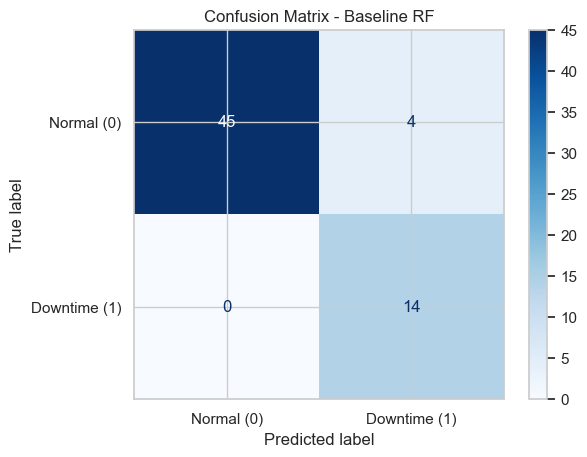

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Downtime (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Baseline RF')
plt.show()

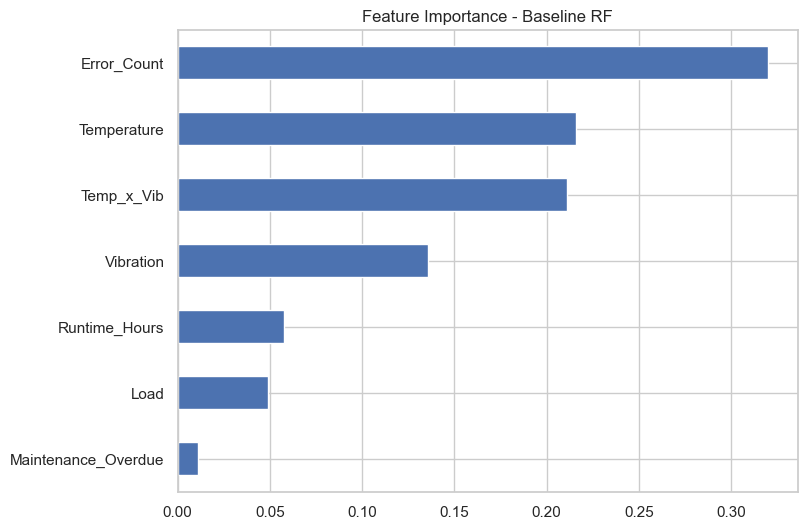

In [27]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Feature Importance - Baseline RF')
plt.show()

In [28]:
# Save model
joblib.dump(rf, 'downtime_rf_model.pkl')
print('Model saved as downtime_rf_model.pkl')

Model saved as downtime_rf_model.pkl


In [29]:
# GridSearchCV to fine-tune parameters (small grid to save time)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy', n_jobs=-1)

In [30]:
# Fit on resampled training data
grid.fit(X_train_scaled, y_train_res)

print('Best parameters:', grid.best_params_)
best_model = grid.best_estimator_

Best parameters: {'max_depth': 8, 'min_samples_split': 10, 'n_estimators': 100}


In [31]:
# Evaluate best model
y_pred_best = best_model.predict(X_test_scaled)
print('Best model accuracy:', accuracy_score(y_test, y_pred_best))
print('\nClassification Report (Best Model):\n', classification_report(y_test, y_pred_best))

Best model accuracy: 0.9365079365079365

Classification Report (Best Model):
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        49
           1       0.78      1.00      0.88        14

    accuracy                           0.94        63
   macro avg       0.89      0.96      0.92        63
weighted avg       0.95      0.94      0.94        63



In [32]:
# Save best model
joblib.dump(best_model, 'downtime_rf_best_model.pkl')
print('Best model saved as downtime_rf_best_model.pkl')

Best model saved as downtime_rf_best_model.pkl


In [33]:
# Cross-validation score
cv_scores = cross_val_score(best_model, scaler.transform(X), y, cv=5, scoring='accuracy')
print('5-fold CV accuracy:', cv_scores, 'Mean:', cv_scores.mean())

5-fold CV accuracy: [0.98 0.98 0.96 0.98 1.  ] Mean: 0.9800000000000001


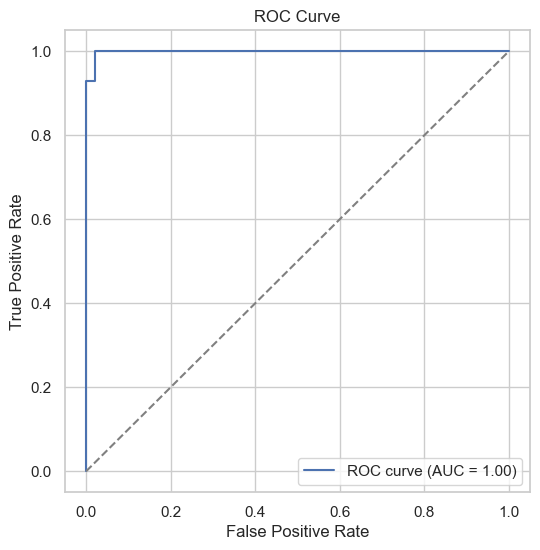

In [34]:
# ROC-AUC curve for best model
from sklearn.metrics import roc_curve, auc

y_proba = best_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [35]:
# Save final artifacts (models and a small report)
import json

artifacts = {
    'best_params': grid.best_params_,
    'cv_mean_accuracy': float(cv_scores.mean())
}
with open('model_report.json','w') as f:
    json.dump(artifacts, f, indent=2)

print('Artifacts saved: model_report.json, downtime_rf_best_model.pkl, scaler.save')

# Display top 5 rows of dataset for quick reference
df.head()


Artifacts saved: model_report.json, downtime_rf_best_model.pkl, scaler.save


,Temperature,Vibration,Load,Runtime_Hours,Error_Count,Maintenance_Overdue,Downtime,Temp_x_Vib
0,74.967142,3.486939,82.295862,592.904524,1,1,0,261.405869
1,68.617357,6.101434,78.538915,821.415576,1,1,0,418.664298
2,76.476885,7.546587,67.804836,1221.560391,2,1,1,577.139502
3,85.230299,6.238958,99.325762,609.320918,3,1,1,531.748280
4,67.658466,3.176756,80.288741,1285.882925,3,0,0,214.934441
